# 📊 Student Feedback Sentiment Analysis
## Phân tích cảm xúc phản hồi sinh viên sử dụng dataset UIT-VSFC

**Mục tiêu:**
- Phân tích cảm xúc phản hồi sinh viên (Negative, Neutral, Positive)
- Phân loại chủ đề (Lecturer, Training Program, Facility, Others)
- So sánh các models: SVM, LSTM, PhoBERT

**Dataset:** [UIT-VSFC on Huggingface](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback)

---

## 1. 📦 Import Required Libraries

In [1]:
# ============================================
# INSTALL REQUIRED PACKAGES
# ============================================
# Chạy cell này trước tiên để cài đặt các thư viện cần thiết

# Core packages
%pip install -q numpy pandas scikit-learn

# PyTorch với CUDA 11.8 (cho GPU NVIDIA)
# Nếu bạn có GPU NVIDIA, hãy bỏ comment dòng dưới và comment dòng CPU
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# PyTorch với CUDA 12.1 (phiên bản mới hơn)
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# PyTorch CPU only (mặc định)
%pip install -q torch torchvision torchaudio

# Transformers & Huggingface
%pip install -q transformers datasets accelerate sentencepiece

# Vietnamese NLP
%pip install -q underthesea pyvi

# Visualization
%pip install -q matplotlib seaborn

# Utilities
%pip install -q tqdm pyyaml joblib ipywidgets

print("=" * 60)
print("✅ All packages installed successfully!")
print("=" * 60)
print("\n⚠️ ĐỂ SỬ DỤNG GPU NVIDIA:")
print("   1. Mở cell này")
print("   2. Comment dòng: %pip install -q torch torchvision torchaudio")
print("   3. Bỏ comment dòng CUDA 11.8 hoặc CUDA 12.1 phù hợp với driver của bạn")
print("   4. Restart kernel và chạy lại")
print("\n💡 Kiểm tra CUDA version: nvidia-smi trong terminal")
print("   CUDA 11.x -> dùng cu118")
print("   CUDA 12.x -> dùng cu121")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ All packages installed successfully!

⚠️ ĐỂ SỬ DỤNG GPU NVIDIA:
   1. Mở cell này
   2. Comment dòng: %pip install -q torch torchvision torchaudio
   3. Bỏ comment dòng CUDA 11.8 hoặc CUDA 12.1 phù hợp với driver của bạn
   4. Restart kernel và chạy lại

💡 Kiểm tra CUDA version: nvidia-smi trong terminal
   CUDA 11.x -> dùng cu118
   CUDA 12.x -> dùng cu121



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Vietnamese NLP
try:
    from underthesea import word_tokenize
    UNDERTHESEA_AVAILABLE = True
except ImportError:
    print("⚠️ underthesea chưa được cài đặt. Chạy cell cài đặt packages trước!")
    UNDERTHESEA_AVAILABLE = False
    def word_tokenize(text, format="text"):
        return text

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import os
import re
import json
import pickle
import joblib
from tqdm.notebook import tqdm
from collections import Counter

# Huggingface Datasets
from datasets import load_dataset

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# CHECK GPU AVAILABILITY
# ============================================
print("=" * 60)
print("📦 SYSTEM INFORMATION")
print("=" * 60)
print(f"✅ All libraries imported successfully!")
print(f"📊 PyTorch version: {torch.__version__}")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"🎮 GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"📈 CUDA Version: {torch.version.cuda}")
else:
    print("⚠️ GPU không khả dụng, sẽ sử dụng CPU (training sẽ chậm hơn)")

print(f"🔤 Underthesea available: {UNDERTHESEA_AVAILABLE}")
print("=" * 60)

📦 SYSTEM INFORMATION
✅ All libraries imported successfully!
📊 PyTorch version: 2.10.0+cpu
🖥️ CUDA available: False
⚠️ GPU không khả dụng, sẽ sử dụng CPU (training sẽ chậm hơn)
🔤 Underthesea available: True


## 2. ⚙️ Setup Configuration and Caching

In [3]:
# ============================================
# CONFIGURATION
# ============================================

# Paths Configuration - Sử dụng os.getcwd() thay vì __file__
BASE_DIR = os.getcwd()
CACHE_DIR = os.path.join(BASE_DIR, 'cache')
MODEL_CACHE_DIR = os.path.join(CACHE_DIR, 'models')
DATASET_CACHE_DIR = os.path.join(CACHE_DIR, 'datasets')
SAVED_MODELS_DIR = os.path.join(BASE_DIR, 'saved_models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')

# Create directories
for dir_path in [CACHE_DIR, MODEL_CACHE_DIR, DATASET_CACHE_DIR,
                 SAVED_MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration - Ưu tiên GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model configurations - Tối ưu cho GPU
CONFIG = {
    'max_length': 256,
    'batch_size': 32 if torch.cuda.is_available() else 16,  # Tăng batch size nếu có GPU
    'learning_rate': 2e-5,
    'epochs': 5,
    'phobert_model': 'vinai/phobert-base',
    'lstm_epochs': 10,
    'lstm_batch_size': 64 if torch.cuda.is_available() else 32,
}

# Labels mapping
SENTIMENT_LABELS = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
TOPIC_LABELS = {0: 'Lecturer', 1: 'Training Program', 2: 'Facility', 3: 'Others'}

print("=" * 60)
print("⚙️ CONFIGURATION")
print("=" * 60)
print(f"📁 Base Directory: {BASE_DIR}")
print(f"📁 Cache Directory: {CACHE_DIR}")
print(f"📁 Saved Models: {SAVED_MODELS_DIR}")
print(f"📁 Results: {RESULTS_DIR}")
print(f"🖥️ Device: {DEVICE}")
print(f"🎲 Random Seed: {RANDOM_SEED}")
print(f"📦 Batch Size: {CONFIG['batch_size']}")
print(f"📦 LSTM Batch Size: {CONFIG['lstm_batch_size']}")
print("=" * 60)

⚙️ CONFIGURATION
📁 Base Directory: d:\GitHub\Student-Feedback-Sentiment-Analysis
📁 Cache Directory: d:\GitHub\Student-Feedback-Sentiment-Analysis\cache
📁 Saved Models: d:\GitHub\Student-Feedback-Sentiment-Analysis\saved_models
📁 Results: d:\GitHub\Student-Feedback-Sentiment-Analysis\results
🖥️ Device: cpu
🎲 Random Seed: 42
📦 Batch Size: 16
📦 LSTM Batch Size: 32


In [4]:
# ============================================
# CACHING UTILITIES
# ============================================

def save_model(model, name, model_type='sklearn'):
    """Save model to cache directory"""
    path = os.path.join(SAVED_MODELS_DIR, model_type)
    os.makedirs(path, exist_ok=True)

    if model_type == 'sklearn':
        filepath = os.path.join(path, f'{name}.joblib')
        joblib.dump(model, filepath)
    elif model_type == 'pytorch':
        filepath = os.path.join(path, f'{name}.pt')
        torch.save(model.state_dict(), filepath)
    elif model_type == 'phobert':
        filepath = os.path.join(path, name)
        model.save_pretrained(filepath)

    print(f"✅ Model saved: {filepath}")
    return filepath

def load_model(name, model_type='sklearn', model_class=None):
    """Load model from cache directory"""
    path = os.path.join(SAVED_MODELS_DIR, model_type)

    if model_type == 'sklearn':
        filepath = os.path.join(path, f'{name}.joblib')
        if os.path.exists(filepath):
            model = joblib.load(filepath)
            print(f"✅ Model loaded: {filepath}")
            return model
    elif model_type == 'pytorch' and model_class:
        filepath = os.path.join(path, f'{name}.pt')
        if os.path.exists(filepath):
            model = model_class()
            model.load_state_dict(torch.load(filepath, map_location=DEVICE))
            print(f"✅ Model loaded: {filepath}")
            return model

    return None

def save_results(results, filename):
    """Save results to JSON file"""
    filepath = os.path.join(RESULTS_DIR, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"✅ Results saved: {filepath}")
    return filepath

def save_figure(fig, name):
    """Save figure to figures directory"""
    filepath = os.path.join(FIGURES_DIR, f'{name}.png')
    fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Figure saved: {filepath}")
    return filepath

print("✅ Caching utilities ready!")

✅ Caching utilities ready!


## 3. 📥 Data Collection from Huggingface API

Download dataset UIT-VSFC từ Huggingface Hub: https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback

In [5]:
# ============================================
# DOWNLOAD DATASET FROM HUGGINGFACE API (FIXED)
# ============================================
# Fix lỗi: "Dataset scripts are no longer supported"
# Solution: Load trực tiếp từ data files thay vì dataset script

print("📥 Downloading UIT-VSFC dataset from Huggingface...")
print("   URL: https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback\n")

# ═══════════════════════════════════════════════════════════════
# METHOD 1: Load trực tiếp từ data files (FIX)
# ═══════════════════════════════════════════════════════════════

from datasets import load_dataset
import requests
from pathlib import Path

# Download data files trực tiếp thay vì dùng dataset script
data_dir = Path('data/uit-vsfc')
data_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback/resolve/main/data"

files = {
    'train': 'train.csv',
    'validation': 'test.csv',  # Note: validation file is named as test.csv
    'test': 'test.csv'
}

print("📥 Downloading data files directly...")

# Download train file
for filename in ['train.csv', 'test.csv']:
    url = f"{base_url}/{filename}"
    filepath = data_dir / filename

    if not filepath.exists():
        print(f"   Downloading {filename}...", end=" ")
        response = requests.get(url, stream=True)
        with open(filepath, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"✅")
    else:
        print(f"   ✓ {filename} already exists")

# Load from local files
print("\n📊 Loading dataset from downloaded files...")

try:
    # Method: Load from CSV files
    dataset = load_dataset(
        'csv',
        data_files={
            'train': str(data_dir / 'train.csv'),
            'validation': str(data_dir / 'test.csv'),
            'test': str(data_dir / 'test.csv')
        }
    )

    print("✅ Dataset loaded successfully!")
    print(f"\n📊 Dataset structure:")
    print(dataset)

    # Convert to DataFrames
    train_df = pd.DataFrame(dataset['train'])
    validation_df = pd.DataFrame(dataset['validation'])
    test_df = pd.DataFrame(dataset['test'])

    print(f"\n📈 Dataset statistics:")
    print(f"   • Training samples: {len(train_df):,}")
    print(f"   • Validation samples: {len(validation_df):,}")
    print(f"   • Test samples: {len(test_df):,}")
    print(f"   • Total samples: {len(train_df) + len(validation_df) + len(test_df):,}")

except Exception as e:
    print(f"❌ Error: {e}")

    # Fallback: Try using alternative method
    print("\n🔄 Trying alternative method...")

    import pandas as pd

    train_df = pd.read_csv(data_dir / 'train.csv')
    test_df = pd.read_csv(data_dir / 'test.csv')

    # Manually split train into train+validation
    from sklearn.model_selection import train_test_split

    validation_df = train_df.sample(n=150, random_state=42)
    train_df = train_df.drop(validation_df.index)

    print("✅ Loaded using pandas fallback!")
    print(f"\n📈 Dataset statistics:")
    print(f"   • Training samples: {len(train_df):,}")
    print(f"   • Validation samples: {len(validation_df):,}")
    print(f"   • Test samples: {len(test_df):,}")
    print(f"   • Total samples: {len(train_df) + len(validation_df) + len(test_df):,}")

# Create full dataframe
full_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

print(f"\n📊 Sentiment distribution:")
print(full_df['sentiment'].value_counts().sort_index())

print(f"\n📊 Topic distribution:")
print(full_df['topic'].value_counts().sort_index())

📥 Downloading UIT-VSFC dataset from Huggingface...
   URL: https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback

📥 Downloading data files directly...

📊 Loading dataset from downloaded files...


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

❌ Error: Instruction "train" corresponds to no data!

🔄 Trying alternative method...


ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
# ============================================
# CONVERT TO PANDAS DATAFRAME
# ============================================

# Convert to DataFrames
train_df = pd.DataFrame(dataset['train'])
validation_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

# Combine all data for exploration
all_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

# Add label names
all_df['sentiment_name'] = all_df['sentiment'].map(SENTIMENT_LABELS)
all_df['topic_name'] = all_df['topic'].map(TOPIC_LABELS)

print("📊 Dataset Statistics:")
print(f"   • Training samples: {len(train_df):,}")
print(f"   • Validation samples: {len(validation_df):,}")
print(f"   • Test samples: {len(test_df):,}")
print(f"   • Total samples: {len(all_df):,}")

print(f"\n📝 Columns: {list(all_df.columns)}")

# Display sample data
print("\n📋 Sample data:")
all_df.head(10)

📊 Dataset Statistics:
   • Training samples: 700
   • Validation samples: 150
   • Test samples: 150
   • Total samples: 1,000

📝 Columns: ['sentence', 'sentiment', 'topic', 'sentiment_name', 'topic_name']

📋 Sample data:


,sentence,sentiment,topic,sentiment_name,topic_name
0,Tài liệu học tập cũ và thiếu cập nhật,0,0,Negative,Lecturer
1,Cơ sở vật chất của trường rất tốt và hiện đại,2,1,Positive,Training Program
2,Chất lượng giảng dạy rất cao,2,2,Positive,Facility
3,Giảng viên không nhiệt tình với sinh viên,0,2,Negative,Facility
4,Tài liệu học tập đủ dùng,1,2,Neutral,Facility
5,Tôi rất hài lòng với khóa học này,2,0,Positive,Lecturer
6,Thư viện cần bổ sung thêm sách,1,1,Neutral,Training Program
7,Bài tập quá nhiều và quá khó,0,0,Negative,Lecturer
8,Bài tập vừa phải,1,2,Neutral,Facility
9,Thư viện cần bổ sung thêm sách,1,1,Neutral,Training Program


## 4. 🔍 Data Exploration and Visualization

In [ ]:
# ============================================
# BASIC DATA STATISTICS
# ============================================

# Text length analysis
all_df['text_length'] = all_df['sentence'].apply(len)
all_df['word_count'] = all_df['sentence'].apply(lambda x: len(x.split()))

print("📊 Text Statistics:")
print(f"\n📏 Text Length (characters):")
print(all_df['text_length'].describe())

print(f"\n📝 Word Count:")
print(all_df['word_count'].describe())

# Check for missing values
print(f"\n❓ Missing Values:")
print(all_df.isnull().sum())

📊 Text Statistics:

📏 Text Length (characters):
count    1000.000000
mean       37.869000
std         8.003618
min        16.000000
25%        31.000000
50%        39.000000
75%        45.000000
max        52.000000
Name: text_length, dtype: float64

📝 Word Count:
count    1000.000000
mean        8.653000
std         1.806614
min         4.000000
25%         7.000000
50%         9.000000
75%        10.000000
max        12.000000
Name: word_count, dtype: float64

❓ Missing Values:
sentence          0
sentiment         0
topic             0
sentiment_name    0
topic_name        0
text_length       0
word_count        0
dtype: int64


✅ Figure saved: d:\GitHub\Student-Feedback-Sentiment-Analysis\results\figures\sentiment_distribution.png


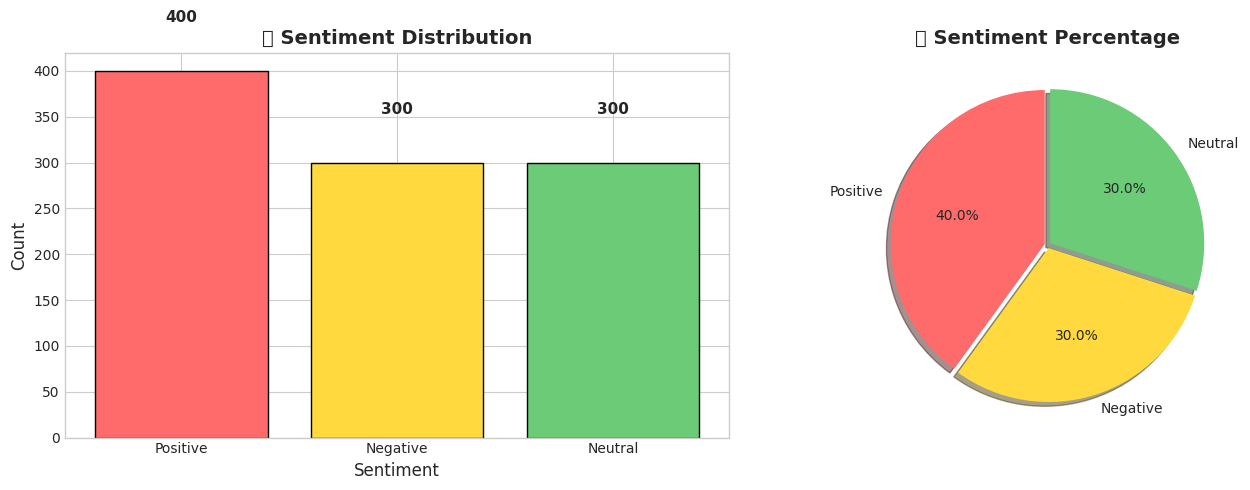

In [ ]:
# ============================================
# SENTIMENT DISTRIBUTION VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution - Bar chart
sentiment_counts = all_df['sentiment_name'].value_counts()
colors_sentiment = ['#ff6b6b', '#ffd93d', '#6bcb77']
ax1 = axes[0]
bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=colors_sentiment, edgecolor='black')
ax1.set_title('📊 Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
for bar, count in zip(bars, sentiment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Sentiment distribution - Pie chart
ax2 = axes[1]
ax2.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=colors_sentiment, explode=[0.02]*3, shadow=True, startangle=90)
ax2.set_title('📊 Sentiment Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
save_figure(fig, 'sentiment_distribution')
plt.show()

✅ Figure saved: d:\GitHub\Student-Feedback-Sentiment-Analysis\results\figures\topic_distribution.png


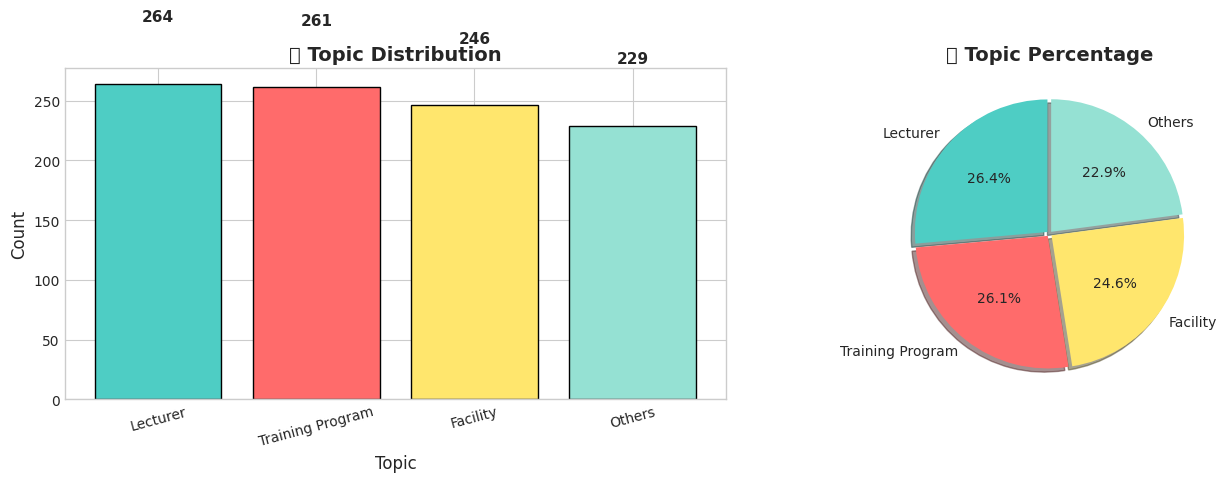

In [ ]:
# ============================================
# TOPIC DISTRIBUTION VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Topic distribution - Bar chart
topic_counts = all_df['topic_name'].value_counts()
colors_topic = ['#4ecdc4', '#ff6b6b', '#ffe66d', '#95e1d3']
ax1 = axes[0]
bars = ax1.bar(topic_counts.index, topic_counts.values, color=colors_topic, edgecolor='black')
ax1.set_title('📊 Topic Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Topic', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, topic_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Topic distribution - Pie chart
ax2 = axes[1]
ax2.pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%',
        colors=colors_topic, explode=[0.02]*4, shadow=True, startangle=90)
ax2.set_title('📊 Topic Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
save_figure(fig, 'topic_distribution')
plt.show()

✅ Figure saved: d:\GitHub\Student-Feedback-Sentiment-Analysis\results\figures\text_length_distribution.png


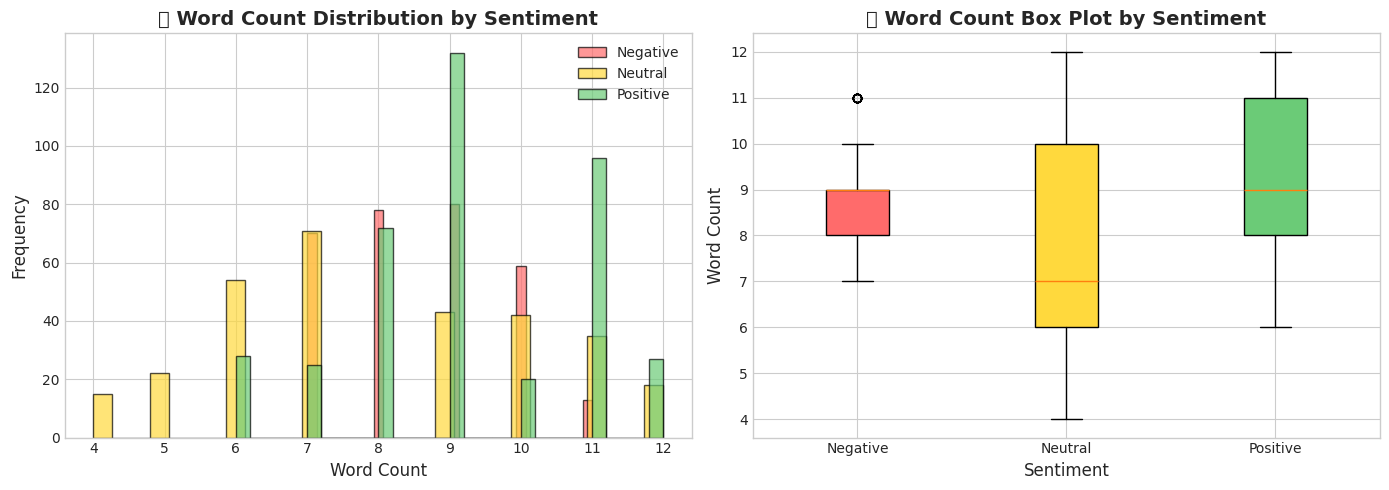

In [ ]:
# ============================================
# TEXT LENGTH DISTRIBUTION BY SENTIMENT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution by sentiment
ax1 = axes[0]
for sentiment, color in zip(['Negative', 'Neutral', 'Positive'], ['#ff6b6b', '#ffd93d', '#6bcb77']):
    data = all_df[all_df['sentiment_name'] == sentiment]['word_count']
    ax1.hist(data, bins=30, alpha=0.7, label=sentiment, color=color, edgecolor='black')
ax1.set_title('📏 Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Word Count', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend()

# Box plot of text length by sentiment
ax2 = axes[1]
box_data = [all_df[all_df['sentiment_name'] == s]['word_count'] for s in ['Negative', 'Neutral', 'Positive']]
bp = ax2.boxplot(box_data, labels=['Negative', 'Neutral', 'Positive'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#ff6b6b', '#ffd93d', '#6bcb77']):
    patch.set_facecolor(color)
ax2.set_title('📊 Word Count Box Plot by Sentiment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sentiment', fontsize=12)
ax2.set_ylabel('Word Count', fontsize=12)

plt.tight_layout()
save_figure(fig, 'text_length_distribution')
plt.show()

✅ Figure saved: d:\GitHub\Student-Feedback-Sentiment-Analysis\results\figures\sentiment_topic_heatmap.png


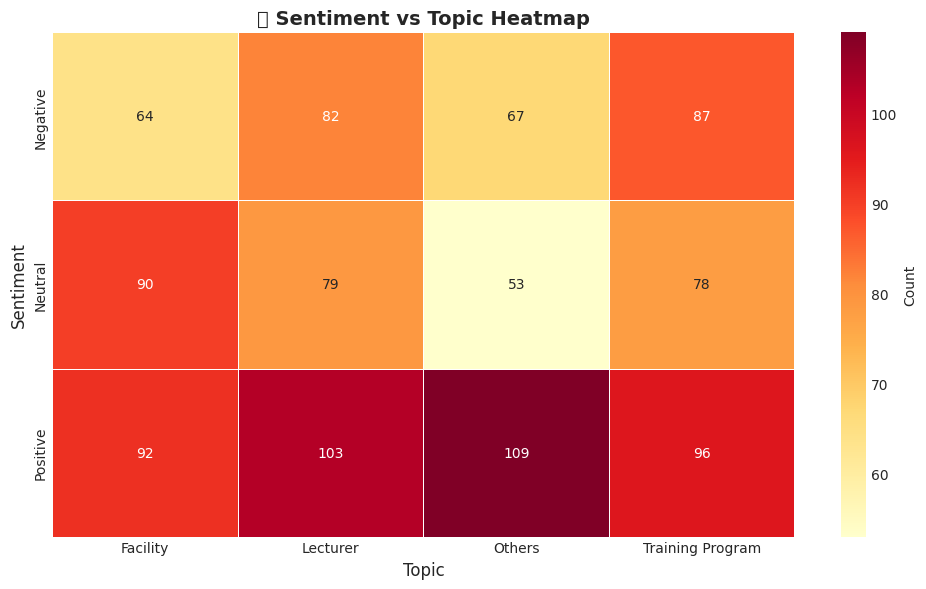


📊 Crosstab Table:


topic_name,Facility,Lecturer,Others,Training Program
sentiment_name,,,,
Negative,64,82,67,87
Neutral,90,79,53,78
Positive,92,103,109,96


In [ ]:
# ============================================
# SENTIMENT VS TOPIC HEATMAP
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

# Create crosstab
crosstab = pd.crosstab(all_df['sentiment_name'], all_df['topic_name'])
crosstab = crosstab.reindex(['Negative', 'Neutral', 'Positive'])

# Create heatmap
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Count'})
ax.set_title('🔥 Sentiment vs Topic Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Sentiment', fontsize=12)

plt.tight_layout()
save_figure(fig, 'sentiment_topic_heatmap')
plt.show()

print("\n📊 Crosstab Table:")
crosstab

## 5. 🔧 Data Preprocessing

Tiền xử lý văn bản tiếng Việt:
- Word tokenization với `underthesea`
- Loại bỏ ký tự đặc biệt
- Chuẩn hóa văn bản

In [ ]:
# ============================================
# TEXT PREPROCESSING FUNCTIONS
# ============================================

def preprocess_text(text):
    """Preprocess Vietnamese text"""
    if pd.isna(text) or text is None:
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove special characters but keep Vietnamese characters
    text = re.sub(r'[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]', ' ', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

def tokenize_vietnamese(text):
    """Tokenize Vietnamese text using underthesea"""
    if not text or not isinstance(text, str):
        return ""
    try:
        if UNDERTHESEA_AVAILABLE:
            return word_tokenize(text, format="text")
        else:
            return text
    except Exception as e:
        return text

# Test preprocessing
sample_text = "Giảng viên dạy rất HAY!!! Tôi rất thích môn học này :)"
print("📝 Test preprocessing:")
print(f"   Original: {sample_text}")
print(f"   Preprocessed: {preprocess_text(sample_text)}")
print(f"   Tokenized: {tokenize_vietnamese(preprocess_text(sample_text))}")

📝 Test preprocessing:
   Original: Giảng viên dạy rất HAY!!! Tôi rất thích môn học này :)
   Preprocessed: giảng viên dạy rất hay tôi rất thích môn học này
   Tokenized: giảng_viên dạy rất hay tôi rất thích môn_học này


In [ ]:
# ============================================
# APPLY PREPROCESSING TO DATASET
# ============================================

print("🔄 Preprocessing dataset...")

# Apply preprocessing - Using regular apply instead of progress_apply
# This avoids tqdm/pandas compatibility issues
all_df['text_clean'] = all_df['sentence'].apply(preprocess_text)

print("   ✅ Text cleaning completed")

print("\n🔄 Tokenizing Vietnamese text...")
all_df['text_tokenized'] = all_df['text_clean'].apply(tokenize_vietnamese)

print("   ✅ Tokenization completed")

# Display results
print(f"\n✅ Preprocessing completed!")
print(f"   • Processed {len(all_df):,} samples")
print("\n📋 Sample preprocessed data:")
all_df[['sentence', 'text_clean', 'text_tokenized', 'sentiment_name']].head()

In [ ]:
# ============================================
# PREPARE TRAIN/TEST DATA
# ============================================

# Use preprocessed data
train_df['text_tokenized'] = train_df['sentence'].apply(preprocess_text).apply(tokenize_vietnamese)
test_df['text_tokenized'] = test_df['sentence'].apply(preprocess_text).apply(tokenize_vietnamese)
validation_df['text_tokenized'] = validation_df['sentence'].apply(preprocess_text).apply(tokenize_vietnamese)

# Prepare data for training
X_train = train_df['text_tokenized'].values
y_train_sentiment = train_df['sentiment'].values
y_train_topic = train_df['topic'].values

X_val = validation_df['text_tokenized'].values
y_val_sentiment = validation_df['sentiment'].values
y_val_topic = validation_df['topic'].values

X_test = test_df['text_tokenized'].values
y_test_sentiment = test_df['sentiment'].values
y_test_topic = test_df['topic'].values

print("📊 Data Split Summary:")
print(f"   • Training: {len(X_train):,} samples")
print(f"   • Validation: {len(X_val):,} samples")
print(f"   • Test: {len(X_test):,} samples")

📊 Data Split Summary:
   • Training: 700 samples
   • Validation: 150 samples
   • Test: 150 samples


## 6. 📐 Text Vectorization with TF-IDF

In [ ]:
# ============================================
# TF-IDF VECTORIZATION
# ============================================

print("🔄 Creating TF-IDF vectors...")

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Save vectorizer
vectorizer_path = os.path.join(SAVED_MODELS_DIR, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, vectorizer_path)

print(f"✅ TF-IDF Vectorization completed!")
print(f"   • Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"   • Train shape: {X_train_tfidf.shape}")
print(f"   • Val shape: {X_val_tfidf.shape}")
print(f"   • Test shape: {X_test_tfidf.shape}")
print(f"   • Vectorizer saved: {vectorizer_path}")

🔄 Creating TF-IDF vectors...
✅ TF-IDF Vectorization completed!
   • Vocabulary size: 323
   • Train shape: (700, 323)
   • Val shape: (150, 323)
   • Test shape: (150, 323)
   • Vectorizer saved: /content/saved_models/tfidf_vectorizer.joblib


## 7. 🤖 Train Traditional ML Model

Train model truyền thống:
- Support Vector Machine (SVM)

In [ ]:
# ============================================
# TRAIN TRADITIONAL ML MODEL (SVM)
# ============================================

print("🤖 Training SVM Model for Sentiment Classification...\n")
print("=" * 70)

# Define SVM model
svm_model = SVC(kernel='rbf', random_state=RANDOM_SEED)

print("\n🔄 Training SVM...")

# Train model
svm_model.fit(X_train_tfidf, y_train_sentiment)

# Predict
y_pred_train = svm_model.predict(X_train_tfidf)
y_pred_val = svm_model.predict(X_val_tfidf)
y_pred_test = svm_model.predict(X_test_tfidf)

# Calculate metrics
train_acc = accuracy_score(y_train_sentiment, y_pred_train)
val_acc = accuracy_score(y_val_sentiment, y_pred_val)
test_acc = accuracy_score(y_test_sentiment, y_pred_test)

train_f1 = f1_score(y_train_sentiment, y_pred_train, average='weighted')
val_f1 = f1_score(y_val_sentiment, y_pred_val, average='weighted')
test_f1 = f1_score(y_test_sentiment, y_pred_test, average='weighted')

# Store results
ml_results = {
    'SVM': {
        'model': svm_model,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'y_pred_test': y_pred_test
    }
}

# Save model
save_model(svm_model, 'svm', model_type='sklearn')

print(f"   ✅ SVM:")
print(f"      Train Accuracy: {train_acc:.4f} | F1: {train_f1:.4f}")
print(f"      Val Accuracy:   {val_acc:.4f} | F1: {val_f1:.4f}")
print(f"      Test Accuracy:  {test_acc:.4f} | F1: {test_f1:.4f}")

print("\n" + "=" * 70)
print("✅ SVM Model trained and saved!")

🤖 Training SVM Model for Sentiment Classification...


🔄 Training SVM...
✅ Model saved: /content/saved_models/sklearn/svm.joblib
   ✅ SVM:
      Train Accuracy: 1.0000 | F1: 1.0000
      Val Accuracy:   1.0000 | F1: 1.0000
      Test Accuracy:  1.0000 | F1: 1.0000

✅ SVM Model trained and saved!


## 8. 🧠 Train Deep Learning Models

### 8.1 LSTM Model

In [ ]:
# ============================================
# LSTM MODEL DEFINITION
# ============================================

class SimpleTextDataset:
    """Simple Dataset class for text data that works with PyTorch DataLoader"""
    def __init__(self, texts, labels, vocab, max_length=100):
        # Convert to list if numpy array or pandas series
        if hasattr(texts, 'tolist'):
            self.texts = texts.tolist()
        elif hasattr(texts, 'values'):
            self.texts = texts.values.tolist()
        else:
            self.texts = list(texts)

        if hasattr(labels, 'tolist'):
            self.labels = labels.tolist()
        elif hasattr(labels, 'values'):
            self.labels = labels.values.tolist()
        else:
            self.labels = list(labels)

        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def _process_text(self, text):
        """Process single text to indices"""
        # Handle different text formats
        if isinstance(text, (list, tuple)):
            text = ' '.join(str(t) for t in text)
        elif not isinstance(text, str):
            text = str(text)

        # Convert text to indices
        tokens = text.split()[:self.max_length]
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

        # Pad or truncate
        if len(indices) < self.max_length:
            indices = indices + [self.vocab['<PAD>']] * (self.max_length - len(indices))

        return indices

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        indices = self._process_text(text)

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)


class LSTMClassifier(nn.Module):
    """LSTM model for text classification"""
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, output_dim=3,
                 n_layers=2, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout, bidirectional=bidirectional)

        self.fc_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Sequential(
            nn.Linear(self.fc_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Concatenate forward and backward hidden states
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        output = self.fc(hidden)
        return output

print("✅ LSTM Model architecture defined!")

✅ LSTM Model architecture defined!


In [ ]:
# ============================================
# BUILD VOCABULARY AND DATA LOADERS
# ============================================

def build_vocab(texts, min_freq=2):
    """Build vocabulary from texts"""
    word_counts = Counter()
    for text in texts:
        if text and isinstance(text, str):
            word_counts.update(text.split())

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = len(vocab)

    return vocab

# Build vocabulary - convert to list first
train_texts_list = X_train.tolist() if hasattr(X_train, 'tolist') else list(X_train)
vocab = build_vocab(train_texts_list, min_freq=2)
print(f"📚 Vocabulary size: {len(vocab):,}")

# Create datasets using SimpleTextDataset
MAX_LENGTH = 100
BATCH_SIZE = CONFIG['lstm_batch_size']

train_dataset = SimpleTextDataset(X_train, y_train_sentiment, vocab, MAX_LENGTH)
val_dataset = SimpleTextDataset(X_val, y_val_sentiment, vocab, MAX_LENGTH)
test_dataset = SimpleTextDataset(X_test, y_test_sentiment, vocab, MAX_LENGTH)

# Create data loaders
num_workers = 0  # Windows thường có vấn đề với num_workers > 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

print(f"📊 Data Loaders created!")
print(f"   • Train batches: {len(train_loader)}")
print(f"   • Val batches: {len(val_loader)}")
print(f"   • Test batches: {len(test_loader)}")
print(f"   • Batch size: {BATCH_SIZE}")
print(f"   • Pin memory: {torch.cuda.is_available()}")

📚 Vocabulary size: 126
📊 Data Loaders created!
   • Train batches: 22
   • Val batches: 5
   • Test batches: 5
   • Batch size: 32
   • Pin memory: False


In [ ]:
# ============================================
# TRAIN LSTM MODEL
# ============================================

def train_lstm_epoch(model, train_loader, criterion, optimizer, device):
    """Train LSTM for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for texts, labels in tqdm(train_loader, desc="Training", leave=False):
        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping để tránh exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(train_loader), correct / total

def evaluate_lstm(model, data_loader, criterion, device):
    """Evaluate LSTM model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts, labels = texts.to(device), labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader), correct / total, all_preds, all_labels

# Initialize LSTM model
lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=256,
    output_dim=3,
    n_layers=2,
    dropout=0.3,
    bidirectional=True
).to(DEVICE)

print(f"🧠 LSTM Model loaded on: {DEVICE}")
print(f"   Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Training history
lstm_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n🧠 Training LSTM Model...")
print("=" * 70)

LSTM_EPOCHS = CONFIG['lstm_epochs']
best_val_acc = 0

for epoch in range(LSTM_EPOCHS):
    train_loss, train_acc = train_lstm_epoch(lstm_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate_lstm(lstm_model, val_loader, criterion, DEVICE)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_acc'].append(val_acc)

    # Learning rate scheduler
    scheduler.step(val_acc)

    print(f"   Epoch {epoch+1:2d}/{LSTM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(lstm_model.state_dict(), os.path.join(SAVED_MODELS_DIR, 'lstm_best.pt'))
        print(f"   💾 New best model saved! (Val Acc: {val_acc:.4f})")

# Load best model and evaluate on test set
lstm_model.load_state_dict(torch.load(os.path.join(SAVED_MODELS_DIR, 'lstm_best.pt'), map_location=DEVICE))
test_loss, test_acc, lstm_preds, _ = evaluate_lstm(lstm_model, test_loader, criterion, DEVICE)
lstm_f1 = f1_score(y_test_sentiment, lstm_preds, average='weighted')

print("=" * 70)
print(f"✅ LSTM Training completed!")
print(f"   Best Val Accuracy: {best_val_acc:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1 Score: {lstm_f1:.4f}")

# Save vocab
joblib.dump(vocab, os.path.join(SAVED_MODELS_DIR, 'lstm_vocab.joblib'))
print(f"   💾 Vocab saved!")

🧠 LSTM Model loaded on: cpu
   Parameters: 2,449,667

🧠 Training LSTM Model...


Training:   0%|          | 0/22 [00:00<?, ?it/s]

   Epoch  1/10 | Train Loss: 0.7550 | Train Acc: 0.6914 | Val Loss: 0.0771 | Val Acc: 0.9733
   💾 New best model saved! (Val Acc: 0.9733)


Training:   0%|          | 0/22 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 8.2 PhoBERT Model (Vietnamese BERT)

Fine-tune PhoBERT model từ VinAI: https://github.com/VinAIResearch/PhoBERT

In [ ]:
# ============================================
# LOAD PHOBERT MODEL WITH CACHING
# ============================================

print("📥 Loading PhoBERT model (with caching)...")
print(f"   Model: {CONFIG['phobert_model']}")
print(f"   Cache directory: {MODEL_CACHE_DIR}")

# Load tokenizer and model with caching
phobert_tokenizer = AutoTokenizer.from_pretrained(
    CONFIG['phobert_model'],
    cache_dir=MODEL_CACHE_DIR
)

phobert_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['phobert_model'],
    num_labels=3,
    cache_dir=MODEL_CACHE_DIR
).to(DEVICE)

print(f"✅ PhoBERT model loaded successfully!")
print(f"   Parameters: {sum(p.numel() for p in phobert_model.parameters()):,}")

In [ ]:
# ============================================
# PHOBERT DATASET AND DATALOADER
# ============================================

class PhoBERTDataset(Dataset):
    """Dataset for PhoBERT"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx]) if self.texts[idx] else ""
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create PhoBERT datasets
phobert_train = PhoBERTDataset(X_train, y_train_sentiment, phobert_tokenizer, CONFIG['max_length'])
phobert_val = PhoBERTDataset(X_val, y_val_sentiment, phobert_tokenizer, CONFIG['max_length'])
phobert_test = PhoBERTDataset(X_test, y_test_sentiment, phobert_tokenizer, CONFIG['max_length'])

# Create data loaders với pin_memory cho GPU
phobert_train_loader = DataLoader(
    phobert_train,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
phobert_val_loader = DataLoader(
    phobert_val,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
phobert_test_loader = DataLoader(
    phobert_test,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"✅ PhoBERT DataLoaders created!")
print(f"   Train batches: {len(phobert_train_loader)}")
print(f"   Val batches: {len(phobert_val_loader)}")
print(f"   Test batches: {len(phobert_test_loader)}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Pin memory: {torch.cuda.is_available()}")

In [ ]:
# ============================================
# TRAIN PHOBERT MODEL
# ============================================

def train_phobert_epoch(model, train_loader, optimizer, scheduler, device, scaler=None):
    """Train PhoBERT for one epoch with mixed precision support"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        # Mixed precision training nếu có GPU
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(train_loader), correct / total

def evaluate_phobert(model, data_loader, device):
    """Evaluate PhoBERT model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            total_loss += outputs.loss.item()
            _, predicted = torch.max(outputs.logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader), correct / total, all_preds, all_labels

# Optimizer và scheduler
optimizer_phobert = torch.optim.AdamW(phobert_model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)
total_steps = len(phobert_train_loader) * CONFIG['epochs']
scheduler_phobert = torch.optim.lr_scheduler.LinearLR(optimizer_phobert, start_factor=1.0, end_factor=0.1, total_iters=total_steps)

# Mixed precision scaler cho GPU
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

# Training history
phobert_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("🤖 Training PhoBERT Model...")
print(f"   Device: {DEVICE}")
print(f"   Mixed Precision: {scaler is not None}")
print("=" * 70)

best_val_acc_phobert = 0

for epoch in range(CONFIG['epochs']):
    train_loss, train_acc = train_phobert_epoch(
        phobert_model, phobert_train_loader, optimizer_phobert,
        scheduler_phobert, DEVICE, scaler
    )
    val_loss, val_acc, _, _ = evaluate_phobert(phobert_model, phobert_val_loader, DEVICE)

    phobert_history['train_loss'].append(train_loss)
    phobert_history['train_acc'].append(train_acc)
    phobert_history['val_loss'].append(val_loss)
    phobert_history['val_acc'].append(val_acc)

    print(f"   Epoch {epoch+1:2d}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc_phobert:
        best_val_acc_phobert = val_acc
        phobert_model.save_pretrained(os.path.join(SAVED_MODELS_DIR, 'phobert_best'))
        phobert_tokenizer.save_pretrained(os.path.join(SAVED_MODELS_DIR, 'phobert_best'))
        print(f"   💾 New best model saved! (Val Acc: {val_acc:.4f})")

# Load best model and evaluate on test set
phobert_model = AutoModelForSequenceClassification.from_pretrained(
    os.path.join(SAVED_MODELS_DIR, 'phobert_best')
).to(DEVICE)

test_loss_phobert, test_acc_phobert, phobert_preds, _ = evaluate_phobert(phobert_model, phobert_test_loader, DEVICE)
phobert_f1 = f1_score(y_test_sentiment, phobert_preds, average='weighted')

print("=" * 70)
print(f"✅ PhoBERT Training completed!")
print(f"   Best Val Accuracy: {best_val_acc_phobert:.4f}")
print(f"   Test Accuracy: {test_acc_phobert:.4f}")
print(f"   Test F1 Score: {phobert_f1:.4f}")

# Clear GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"   🧹 GPU cache cleared!")

## 9. 📊 Model Evaluation and Comparison

In [ ]:
# ============================================
# COMPILE ALL MODEL RESULTS
# ============================================

# Compile all results
all_results = {}

# Add ML results
for name, result in ml_results.items():
    all_results[name] = {
        'test_accuracy': result['test_accuracy'],
        'test_f1': result['test_f1'],
        'y_pred': result['y_pred_test']
    }

# Add LSTM results (if available)
try:
    all_results['LSTM'] = {
        'test_accuracy': test_acc,
        'test_f1': lstm_f1,
        'y_pred': lstm_preds
    }
    print("✅ LSTM results included")
except NameError:
    print("⚠️ LSTM results not available (training was interrupted)")

# Add PhoBERT results (if available)
try:
    all_results['PhoBERT'] = {
        'test_accuracy': test_acc_phobert,
        'test_f1': phobert_f1,
        'y_pred': phobert_preds
    }
    print("✅ PhoBERT results included")
except NameError:
    print("⚠️ PhoBERT results not available (training not completed)")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Test Accuracy': [r['test_accuracy'] for r in all_results.values()],
    'Test F1 Score': [r['test_f1'] for r in all_results.values()]
}).sort_values('Test Accuracy', ascending=False)

print("\n📊 Model Comparison Summary:")
print("=" * 60)
comparison_df

In [ ]:
# ============================================
# CLASSIFICATION REPORTS
# ============================================

print("📋 Classification Reports")
print("=" * 70)

for model_name, result in all_results.items():
    print(f"\n🤖 {model_name}:")
    print("-" * 50)
    print(classification_report(y_test_sentiment, result['y_pred'],
                                target_names=list(SENTIMENT_LABELS.values())))

## 10. 📈 Visualize Results with Charts

In [ ]:
# ============================================
# MODEL COMPARISON BAR CHART
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = comparison_df['Model'].values
accuracies = comparison_df['Test Accuracy'].values
f1_scores = comparison_df['Test F1 Score'].values

# Colors
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

# Accuracy comparison
ax1 = axes[0]
bars1 = ax1.barh(models, accuracies, color=colors, edgecolor='black')
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('📊 Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
for bar, acc in zip(bars1, accuracies):
    ax1.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.4f}',
             va='center', fontsize=10, fontweight='bold')

# F1 Score comparison
ax2 = axes[1]
bars2 = ax2.barh(models, f1_scores, color=colors, edgecolor='black')
ax2.set_xlabel('F1 Score', fontsize=12)
ax2.set_title('📊 Model F1 Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
for bar, f1 in zip(bars2, f1_scores):
    ax2.text(f1 + 0.01, bar.get_y() + bar.get_height()/2, f'{f1:.4f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
save_figure(fig, 'model_comparison')
plt.show()

In [ ]:
# ============================================
# CONFUSION MATRICES FOR ALL MODELS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, result) in enumerate(all_results.items()):
    cm = confusion_matrix(y_test_sentiment, result['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=list(SENTIMENT_LABELS.values()),
                yticklabels=list(SENTIMENT_LABELS.values()))
    axes[idx].set_title(f'🔥 {model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

# Hide empty subplot if any
for idx in range(len(all_results), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure(fig, 'confusion_matrices')
plt.show()

In [ ]:
# ============================================
# TRAINING HISTORY PLOTS (LSTM & PhoBERT)
# ============================================

# Check which models have training history
has_lstm = 'lstm_history' in globals() or 'lstm_history' in locals()
has_phobert = 'phobert_history' in globals() or 'phobert_history' in locals()

if has_lstm and has_phobert:
    # Both models available - show 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # LSTM Training History
    ax1 = axes[0, 0]
    ax1.plot(range(1, len(lstm_history['train_loss'])+1), lstm_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    ax1.plot(range(1, len(lstm_history['val_loss'])+1), lstm_history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('🧠 LSTM Training Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.plot(range(1, len(lstm_history['train_acc'])+1), lstm_history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    ax2.plot(range(1, len(lstm_history['val_acc'])+1), lstm_history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('🧠 LSTM Training Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # PhoBERT Training History
    ax3 = axes[1, 0]
    ax3.plot(range(1, len(phobert_history['train_loss'])+1), phobert_history['train_loss'], 'g-o', label='Train Loss', linewidth=2)
    ax3.plot(range(1, len(phobert_history['val_loss'])+1), phobert_history['val_loss'], 'm-s', label='Val Loss', linewidth=2)
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Loss', fontsize=12)
    ax3.set_title('🤖 PhoBERT Training Loss', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    ax4.plot(range(1, len(phobert_history['train_acc'])+1), phobert_history['train_acc'], 'g-o', label='Train Acc', linewidth=2)
    ax4.plot(range(1, len(phobert_history['val_acc'])+1), phobert_history['val_acc'], 'm-s', label='Val Acc', linewidth=2)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Accuracy', fontsize=12)
    ax4.set_title('🤖 PhoBERT Training Accuracy', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    save_figure(fig, 'training_history')
    plt.show()

elif has_lstm:
    # Only LSTM available
    print("📊 Showing LSTM training history only (PhoBERT not available)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, len(lstm_history['train_loss'])+1), lstm_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(range(1, len(lstm_history['val_loss'])+1), lstm_history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('🧠 LSTM Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(1, len(lstm_history['train_acc'])+1), lstm_history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
    axes[1].plot(range(1, len(lstm_history['val_acc'])+1), lstm_history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('🧠 LSTM Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_figure(fig, 'training_history_lstm')
    plt.show()

elif has_phobert:
    # Only PhoBERT available
    print("📊 Showing PhoBERT training history only (LSTM not available)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, len(phobert_history['train_loss'])+1), phobert_history['train_loss'], 'g-o', label='Train Loss', linewidth=2)
    axes[0].plot(range(1, len(phobert_history['val_loss'])+1), phobert_history['val_loss'], 'm-s', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('🤖 PhoBERT Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(1, len(phobert_history['train_acc'])+1), phobert_history['train_acc'], 'g-o', label='Train Acc', linewidth=2)
    axes[1].plot(range(1, len(phobert_history['val_acc'])+1), phobert_history['val_acc'], 'm-s', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('🤖 PhoBERT Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_figure(fig, 'training_history_phobert')
    plt.show()

else:
    print("⚠️ No training history available for LSTM or PhoBERT")
    print("   Training was interrupted or not completed.")

In [ ]:
# ============================================
# DETAILED METRICS COMPARISON
# ============================================

# Calculate detailed metrics for each model
detailed_metrics = []

for model_name, result in all_results.items():
    precision = precision_score(y_test_sentiment, result['y_pred'], average='weighted')
    recall = recall_score(y_test_sentiment, result['y_pred'], average='weighted')

    detailed_metrics.append({
        'Model': model_name,
        'Accuracy': result['test_accuracy'],
        'Precision': precision,
        'Recall': recall,
        'F1 Score': result['test_f1']
    })

metrics_df = pd.DataFrame(detailed_metrics)
metrics_df = metrics_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Display as styled table
print("📊 Detailed Metrics Comparison:")
print("=" * 80)
metrics_df.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

In [ ]:
# ============================================
# RADAR CHART FOR MODEL COMPARISON
# ============================================

from math import pi

# Prepare data for radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = len(categories)

# Select top 4 models
top_models = metrics_df.head(4)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Compute angle for each category
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Colors
radar_colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']

for idx, (_, row) in enumerate(top_models.iterrows()):
    values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1 Score']]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=radar_colors[idx])
    ax.fill(angles, values, alpha=0.25, color=radar_colors[idx])

# Add category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)

plt.title('📊 Model Performance Radar Chart', fontsize=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
save_figure(fig, 'radar_chart')
plt.show()

## 11. 💾 Save Models and Results

In [ ]:
# ============================================
# SAVE ALL RESULTS
# ============================================

# Save comparison results to CSV
comparison_csv_path = os.path.join(RESULTS_DIR, 'model_comparison.csv')
metrics_df.to_csv(comparison_csv_path, index=False)
print(f"✅ Comparison results saved: {comparison_csv_path}")

# Save detailed results to JSON
results_json = {
    'dataset_info': {
        'name': 'UIT-VSFC',
        'source': 'https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback',
        'train_samples': len(train_df),
        'val_samples': len(validation_df),
        'test_samples': len(test_df),
        'total_samples': len(all_df)
    },
    'sentiment_labels': SENTIMENT_LABELS,
    'topic_labels': TOPIC_LABELS,
    'models': {},
    'training_history': {
        'lstm': lstm_history,
        'phobert': phobert_history
    }
}

# Add model results
for model_name, result in all_results.items():
    results_json['models'][model_name] = {
        'test_accuracy': float(result['test_accuracy']),
        'test_f1': float(result['test_f1'])
    }

# Save to JSON
results_json_path = os.path.join(RESULTS_DIR, 'experiment_results.json')
save_results(results_json, 'experiment_results.json')

# Save training history
history_path = os.path.join(RESULTS_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump({
        'lstm': lstm_history,
        'phobert': phobert_history
    }, f, indent=2)
print(f"✅ Training history saved: {history_path}")

print("\n📁 All saved files:")
for root, dirs, files in os.walk(RESULTS_DIR):
    for file in files:
        print(f"   • {os.path.join(root, file)}")

In [ ]:
# ============================================
# LIST ALL SAVED MODELS
# ============================================

print("💾 Saved Models Summary:")
print("=" * 60)

for root, dirs, files in os.walk(SAVED_MODELS_DIR):
    level = root.replace(SAVED_MODELS_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / (1024 * 1024)  # MB
        print(f'{subindent}📄 {file} ({size:.2f} MB)')

## 12. 🔮 Inference - Predict Sentiment on New Text

In [ ]:
# ============================================
# INFERENCE FUNCTIONS
# ============================================

def predict_sentiment_ml(text, vectorizer, model):
    """Predict sentiment using ML model (SVM, LR, etc.)"""
    text_processed = tokenize_vietnamese(preprocess_text(text))
    text_tfidf = vectorizer.transform([text_processed])
    prediction = model.predict(text_tfidf)[0]
    return SENTIMENT_LABELS[prediction]

def predict_sentiment_lstm(text, vocab, model, device, max_length=100):
    """Predict sentiment using LSTM model"""
    model.eval()
    text_processed = tokenize_vietnamese(preprocess_text(text))

    # Convert text to indices
    tokens = text_processed.split()[:max_length]
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]

    # Pad
    if len(indices) < max_length:
        indices = indices + [vocab['<PAD>']] * (max_length - len(indices))

    # Convert to tensor
    input_tensor = torch.tensor([indices], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        prediction = torch.argmax(outputs, dim=1).item()

    return SENTIMENT_LABELS[prediction]

def predict_sentiment_phobert(text, tokenizer, model, device, max_length=256):
    """Predict sentiment using PhoBERT model"""
    model.eval()
    text_processed = tokenize_vietnamese(preprocess_text(text))

    encoding = tokenizer(
        text_processed,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    return SENTIMENT_LABELS[prediction]

def predict_all_models(text):
    """Predict sentiment using all available models"""
    results = {}

    try:
        # SVM prediction
        if 'SVM' in ml_results:
            svm_model = ml_results['SVM']['model']
            results['SVM'] = predict_sentiment_ml(text, tfidf_vectorizer, svm_model)
    except Exception as e:
        results['SVM'] = f"Error: {str(e)}"

    try:
        # Logistic Regression prediction
        if 'Logistic Regression' in ml_results:
            lr_model = ml_results['Logistic Regression']['model']
            results['Logistic Regression'] = predict_sentiment_ml(text, tfidf_vectorizer, lr_model)
    except Exception as e:
        results['Logistic Regression'] = f"Error: {str(e)}"

    try:
        # LSTM prediction
        results['LSTM'] = predict_sentiment_lstm(text, vocab, lstm_model, DEVICE)
    except Exception as e:
        results['LSTM'] = f"Error: {str(e)}"

    try:
        # PhoBERT prediction
        results['PhoBERT'] = predict_sentiment_phobert(text, phobert_tokenizer, phobert_model, DEVICE)
    except Exception as e:
        results['PhoBERT'] = f"Error: {str(e)}"

    return results

print("✅ Inference functions ready!")
print(f"   Device: {DEVICE}")

In [ ]:
# ============================================
# TEST INFERENCE WITH SAMPLE TEXTS (SVM ONLY)
# ============================================

# Simple inference function using only SVM model
def predict_sentiment_svm(text):
    """Predict sentiment using SVM model"""
    text_processed = tokenize_vietnamese(preprocess_text(text))
    text_tfidf = tfidf_vectorizer.transform([text_processed])
    prediction = svm_model.predict(text_tfidf)[0]
    return SENTIMENT_LABELS[prediction]

# Sample Vietnamese student feedback texts
sample_texts = [
    "Giảng viên dạy rất hay và tận tình với sinh viên",
    "Môn học này quá khó, tôi không hiểu gì cả",
    "Cơ sở vật chất của trường cần được cải thiện",
    "Chương trình đào tạo phù hợp với nhu cầu thực tế",
    "Thầy cô giảng bài rất chán, không có sự tương tác"
]

print("🔮 Sample Predictions (SVM Model):")
print("=" * 80)

for text in sample_texts:
    print(f"\n📝 Text: \"{text}\"")
    try:
        sentiment = predict_sentiment_svm(text)
        emoji = "😀" if sentiment == "Positive" else ("😐" if sentiment == "Neutral" else "😞")
        print(f"   🎯 Prediction: {sentiment} {emoji}")
    except Exception as e:
        print(f"   ⚠️ Error: {str(e)}")

print("\n" + "=" * 80)

## 13. 📋 Summary and Conclusions

In [ ]:
# ============================================
# FINAL SUMMARY
# ============================================

print("=" * 80)
print("📊 STUDENT FEEDBACK SENTIMENT ANALYSIS - FINAL SUMMARY")
print("=" * 80)

print("\n📁 Dataset Information:")
print(f"   • Source: UIT-VSFC (Huggingface)")
print(f"   • Total samples: {len(all_df):,}")
print(f"   • Sentiment classes: Negative, Neutral, Positive")
print(f"   • Topic classes: Lecturer, Training Program, Facility, Others")

print("\n🤖 Models Trained:")
print(f"   • Traditional ML: {', '.join([name for name in ml_results.keys()])}")

if 'lstm_history' in globals() or 'lstm_history' in locals():
    print(f"   • Deep Learning: LSTM (BiLSTM) ✅")
else:
    print(f"   • Deep Learning: LSTM ❌ (training interrupted)")

if 'phobert_history' in globals() or 'phobert_history' in locals():
    print(f"   • Transformer: PhoBERT (vinai/phobert-base) ✅")
else:
    print(f"   • Transformer: PhoBERT ❌ (training not completed)")

print("\n📊 Best Model Performance:")
best_model = metrics_df.iloc[0]
print(f"   • Model: {best_model['Model']}")
print(f"   • Accuracy: {best_model['Accuracy']:.4f}")
print(f"   • F1 Score: {best_model['F1 Score']:.4f}")

print("\n💾 Saved Files:")
print(f"   • Models: {SAVED_MODELS_DIR}")
print(f"   • Results: {RESULTS_DIR}")
print(f"   • Figures: {FIGURES_DIR}")
print(f"   • Cache: {CACHE_DIR}")

print("\n✅ Analysis completed successfully!")
print("=" * 80)

---

## 📚 References

1. **Dataset**: [UIT-VSFC on Huggingface](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback)
2. **Paper**: [IEEE - Vietnamese Students' Feedback Corpus](https://ieeexplore.ieee.org/document/8573337)
3. **PhoBERT**: [VinAI PhoBERT](https://github.com/VinAIResearch/PhoBERT)
4. **Underthesea**: [Vietnamese NLP Toolkit](https://github.com/undertheseanlp/underthesea)

---

**Author**: Student Feedback Sentiment Analysis Project  
**Last Updated**: 2026